# Step D — Interconnected system with DC power flow

**Task (Assignment 1, part d):** Connect Denmark to at least three neighbouring countries
using HVAC lines (at least one closed cycle in the network). Use ENTSO-E NTC values for
line capacities, assume 400 kV nominal voltage and x = 0.1 pu reactance. Neighbour
generation capacities are **fixed** to their 2015 values (ENTSO-E / IEA). Optimise the
whole system using the linearised AC power flow (DC approximation).

**Network topology (5 lines, 2 closed loops: DK-DE-SE-DK and DK-NO-SE-DK):**

| Line | Capacity [MW] | Length [km] |
|------|---:|---:|
| DK – DE | 3500 | 360 |
| DK – SE | 1700 | 520 |
| DK – NO | 1050 | 570 |
| SE – NO | 3500 | 480 |
| DE – SE |  600 | 820 |

**Requires in the working directory:**
- `DK_2015_merged.csv`
- `STEP D - electricity_demand.csv` (semicolon-delimited multi-country demand file)
- `Other country data/Energy charts data/{Germany,Sweden,Norway}/<country>_hourly_capacity_factors.csv`
- `functions_to_investigate.py`


## Imports

In [23]:
from pathlib import Path
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import functions_to_investigate as fti


## Rebuild Step A baseline (needed for the Denmark comparison at the end)

Step D compares Denmark's optimal capacities to the isolated Step A case, so we rebuild
the Step A network here (`dnk_n`). We also recreate the `costs` table used for Denmark's
extendable generators.


In [24]:
# 2015 Danish data
dataframe_dk_stepA = pd.read_csv("DK_2015_merged.csv", index_col=0, sep=",", parse_dates=True)
demand_dk_stepA = dataframe_dk_stepA["DK_load_actual_entsoe_transparency"]
CF_wind_stepA = dataframe_dk_stepA["wind_cf_Unnamed: 1"]
CF_solar_stepA = dataframe_dk_stepA["pv_cf_Unnamed: 1"]

# Cost table (identical to Step A)
data = {
    "capital_cost": [
        1500000/25 + 60000,   # wind:  120,000 $/MW/year
        800000/25 + 14000,    # solar:  46,000 $/MW/year
        700000/25 + 24000,    # CCGT:   52,000 $/MW/year
    ],
    "marginal_cost": [0.0, 0.0, 9.5 * 3.6 / 0.56 + 2.30]  # CCGT: ~63.4 $/MWh
}
costs = pd.DataFrame(data, index=["wind_combined", "solar", "CCGT"])

dnk_n = pypsa.Network()
dnk_n.set_snapshots(dataframe_dk_stepA.index.values)
dnk_n.add("Bus", "Denmark")
dnk_n.add("Carrier", ["wind_combined", "solar", "CCGT"], color=["blue", "red", "brown"])
dnk_n.add("Load", "dnk_demand", bus="Denmark", p_set=demand_dk_stepA.values)
dnk_n.add("Generator", "wind_combined", bus="Denmark", carrier="wind_combined",
          capital_cost=costs.loc["wind_combined", "capital_cost"],
          marginal_cost=costs.loc["wind_combined", "marginal_cost"],
          p_max_pu=CF_wind_stepA.values, p_nom_extendable=True)
dnk_n.add("Generator", "solar", bus="Denmark", carrier="solar",
          capital_cost=costs.loc["solar", "capital_cost"],
          marginal_cost=costs.loc["solar", "marginal_cost"],
          p_max_pu=CF_solar_stepA.values, p_nom_extendable=True)
dnk_n.add("Generator", "CCGT", bus="Denmark", carrier="CCGT",
          capital_cost=costs.loc["CCGT", "capital_cost"],
          marginal_cost=costs.loc["CCGT", "marginal_cost"],
          efficiency=0.58, p_nom_extendable=True)
dnk_n.optimize(solver_name="gurobi", solver_options={"output_flag": False})
print(f"Step A rebuilt (isolated Denmark) — system cost: {dnk_n.objective/1e9:.3f} B$/y")


C:\Users\terry\AppData\Local\Temp\ipykernel_25320\1752915285.py:35: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - output_flag: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 1944.51it/s]
INFO:linopy.io: Writing time: 0.05s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


INFO:gurobipy:Set parameter LicenseID to value 2773895


...

Reading time = 0.07 seconds


INFO:gurobipy:Reading time = 0.07 seconds


obj: 61323 rows, 26283 columns, 100707 nonzeros


INFO:gurobipy:obj: 61323 rows, 26283 columns, 100707 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 26283 primals, 61323 duals
Objective: 1.87e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


Step A rebuilt (isolated Denmark) — system cost: 1.873 B$/y


## D1 — Load hourly demand for all four countries

In [25]:
# -- CELL D1 ----------------------------------------------------
# Load hourly demand data for all four countries used in Step D

# Resolve project root robustly (works whether cwd is project root or subfolder)
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "STEP D - electricity_demand.csv").exists():
    PROJECT_DIR = PROJECT_DIR.parent

demand_path = PROJECT_DIR / "STEP D - electricity_demand.csv"
if not demand_path.exists():
    raise FileNotFoundError(f"Could not find demand file at: {demand_path}")

demand_all = pd.read_csv(
    demand_path,
    sep=";",
    index_col=0,
    parse_dates=True
)

# Keep only 2015 rows and the four countries we need
# Convert to timezone-naive (PyPSA requirement)
demand_all.index = pd.to_datetime(demand_all.index, utc=True).tz_localize(None)
demand_all = demand_all.sort_index()
demand_2015 = demand_all[demand_all.index.year == 2015].copy()

# Column names in the CSV use 3-letter country codes
demand_dk = demand_2015["DNK"].astype(float)
demand_de = demand_2015["DEU"].astype(float)
demand_se = demand_2015["SWE"].astype(float)
demand_no = demand_2015["NOR"].astype(float)

print("Demand shapes (should all be 8760 rows):")
print(f"  DK: {demand_dk.shape},  DE: {demand_de.shape},  SE: {demand_se.shape},  NO: {demand_no.shape}")

assert len(demand_dk) == 8760, "Denmark demand is not 8760 hours."
assert len(demand_de) == 8760, "Germany demand is not 8760 hours."
assert len(demand_se) == 8760, "Sweden demand is not 8760 hours."
assert len(demand_no) == 8760, "Norway demand is not 8760 hours."

print("\nAnnual demand [TWh]:")
print(f"  Denmark: {demand_dk.sum()/1e6:.2f}")
print(f"  Germany: {demand_de.sum()/1e6:.2f}")
print(f"  Sweden:  {demand_se.sum()/1e6:.2f}")
print(f"  Norway:  {demand_no.sum()/1e6:.2f}")


Demand shapes (should all be 8760 rows):
  DK: (8760,),  DE: (8760,),  SE: (8760,),  NO: (8760,)

Annual demand [TWh]:
  Denmark: 32.81
  Germany: 505.26
  Sweden:  135.93
  Norway:  128.65


## D1.5 — Load capacity factor data for neighbouring countries

From the Energy Charts time series (2015, hourly). Germany is downsampled from 15-min to
hourly by averaging.


In [26]:
# Cell 1.5
# Make this cell runnable on its own
if "PROJECT_DIR" not in globals():
    PROJECT_DIR = Path.cwd()
    if not (PROJECT_DIR / "STEP D - electricity_demand.csv").exists():
        PROJECT_DIR = PROJECT_DIR.parent

cf_base = PROJECT_DIR / "Other country data" / "Energy charts data"

# --------------------------------------------------
# 1. Read snapshot reference from Denmark / Step A
# --------------------------------------------------
dataframe_dk = pd.read_csv(PROJECT_DIR / "DK_2015_merged.csv", index_col=0, parse_dates=True)
snapshots = pd.DatetimeIndex(dataframe_dk.index)

# Optional but often useful:
snapshots = snapshots.tz_localize(None)

# --------------------------------------------------
# 2. Germany: read + convert 15-min to hourly
# --------------------------------------------------
cf_de_raw = pd.read_csv(cf_base / "Germany" / "Germany_hourly_capacity_factors.csv")
cf_de_raw["timestamp"] = pd.to_datetime(cf_de_raw["timestamp"])
cf_de_raw = cf_de_raw.set_index("timestamp").sort_index()
cf_de_raw.index = cf_de_raw.index.tz_localize(None)

# Convert 15-min to hourly by averaging
cf_de = cf_de_raw.resample("h").mean()

# Keep only the technologies you need
cf_de["wind_combined"] = cf_de["Wind onshore"]   # for now; add offshore separately only if you model it
cf_de["solar"] = cf_de["Solar AC"]
cf_de["CCGT"] = cf_de["Fossil gas"]
cf_de["nuclear"] = cf_de["Nuclear"]

# If you keep coal fixed without p_max_pu, no need for coal profile
cf_de = cf_de[["wind_combined", "solar", "CCGT", "nuclear"]]

# Align exactly to model snapshots
cf_de = cf_de.reindex(snapshots)

# --------------------------------------------------
# 3. Sweden: read hourly data
# --------------------------------------------------
cf_se = pd.read_csv(cf_base / "Sweden" / "Sweden_hourly_capacity_factors.csv")
cf_se["timestamp"] = pd.to_datetime(cf_se["timestamp"])
cf_se = cf_se.set_index("timestamp").sort_index()
cf_se.index = cf_se.index.tz_localize(None)

cf_se["wind_combined"] = cf_se["Wind onshore"]
cf_se["nuclear"] = cf_se["Nuclear"]
cf_se["hydro"] = cf_se["Hydro water reservoir"]

cf_se = cf_se[["wind_combined", "nuclear", "hydro"]]
cf_se = cf_se.reindex(snapshots)
cf_se = cf_se.bfill()

# --------------------------------------------------
# 4. Norway: read hourly data
# --------------------------------------------------
cf_no = pd.read_csv(cf_base / "Norway" / "Norway_hourly_capacity_factors.csv")
cf_no["timestamp"] = pd.to_datetime(cf_no["timestamp"])
cf_no = cf_no.set_index("timestamp").sort_index()
cf_no.index = cf_no.index.tz_localize(None)

cf_no["wind_combined"] = cf_no["Wind onshore"]
cf_no["hydro"] = cf_no["Hydro water reservoir"]
cf_no["CCGT"] = cf_no["Fossil gas"]   # only if you later choose to model Norwegian gas

cf_no = cf_no[["wind_combined", "hydro"]]
cf_no = cf_no.reindex(snapshots)

# --------------------------------------------------
# 5. Basic checks — leaving them as is for now.
# --------------------------------------------------
print("Germany shape:", cf_de.shape)
print("Sweden shape:", cf_se.shape)
print("Norway shape:", cf_no.shape)

print("\nMissing values:")
print("Germany\n", cf_de.isna().sum())
print("Sweden\n", cf_se.isna().sum())
print("Norway\n", cf_no.isna().sum())


Germany shape: (8760, 4)
Sweden shape: (8760, 3)
Norway shape: (8760, 2)

Missing values:
Germany
 wind_combined    1
solar            1
CCGT             1
nuclear          1
dtype: int64
Sweden
 wind_combined    1
nuclear          1
hydro            1
dtype: int64
Norway
 wind_combined    74
hydro             2
dtype: int64


## D2 — Build the network: 4 buses, snapshots, Denmark CFs

In [27]:
# ── CELL D2 ─────────────────────────────────────────────────
# Build the network: 4 buses, aligned snapshots, and country-level demand

# Re-load 2015 Danish wind/solar capacity factors
dataframe_dk = pd.read_csv("DK_2015_merged.csv", index_col=0, sep=",", parse_dates=True)
# Convert to timezone-naive (PyPSA requirement)
dataframe_dk.index = pd.to_datetime(dataframe_dk.index, utc=True).tz_localize(None)
dataframe_dk = dataframe_dk.sort_index()

CF_wind = dataframe_dk["wind_cf_Unnamed: 1"].astype(float)
CF_solar = dataframe_dk["pv_cf_Unnamed: 1"].astype(float)

# Use the Danish CF index as the master snapshot index
snapshots = dataframe_dk.index

# Align all Step D demand series to the exact same hourly index
demand_dk = demand_dk.reindex(snapshots)
demand_de = demand_de.reindex(snapshots)
demand_se = demand_se.reindex(snapshots)
demand_no = demand_no.reindex(snapshots)

assert demand_dk.notna().all(), "Denmark demand has missing values after alignment."
assert demand_de.notna().all(), "Germany demand has missing values after alignment."
assert demand_se.notna().all(), "Sweden demand has missing values after alignment."
assert demand_no.notna().all(), "Norway demand has missing values after alignment."
assert CF_wind.notna().all(), "Wind capacity factor has missing values."
assert CF_solar.notna().all(), "Solar capacity factor has missing values."

# ---- Create the network ----
net = pypsa.Network()
net.set_snapshots(snapshots)

# ---- Add 4 buses (one per country) ----
buses = {
    "Denmark": (10.0, 56.0),
    "Germany": (10.5, 51.5),
    "Sweden":  (15.0, 59.5),
    "Norway":  (10.0, 62.0),
}
for name, (x, y) in buses.items():
    net.add("Bus", name, x=x, y=y)

print("Buses added:", list(net.buses.index))
print(f"Snapshots set: {len(net.snapshots)} hours")


Buses added: ['Denmark', 'Germany', 'Sweden', 'Norway']
Snapshots set: 8760 hours


## D3 — Loads (one per country)

In [28]:
# ── CELL D3 ─────────────────────────────────────────────────
# Add electricity demand (Load) for each country

net.add("Load", "load_DK", bus="Denmark", p_set=demand_dk.values)
net.add("Load", "load_DE", bus="Germany", p_set=demand_de.values)
net.add("Load", "load_SE", bus="Sweden", p_set=demand_se.values)
net.add("Load", "load_NO", bus="Norway", p_set=demand_no.values)

print("Total annual demand [TWh]:")
print(f"  Denmark: {demand_dk.sum()/1e6:.2f}")
print(f"  Germany: {demand_de.sum()/1e6:.2f}")
print(f"  Sweden:  {demand_se.sum()/1e6:.2f}")
print(f"  Norway:  {demand_no.sum()/1e6:.2f}")


Total annual demand [TWh]:
  Denmark: 32.81
  Germany: 505.26
  Sweden:  135.93
  Norway:  128.65


In [29]:
# ── CELL D3b ─────────────────────────────────────────────────
# Demand diagnostics: monthly and daily peak demand for each country

# Build one dataframe with hourly demand
demand_df = pd.DataFrame({
    "Denmark": demand_dk.values,
    "Germany": demand_de.values,
    "Sweden":  demand_se.values,
    "Norway":  demand_no.values,
}, index=net.snapshots)

# ---- 1) Monthly peak hourly demand ----
monthly_peak = demand_df.resample("ME").max()   # month-end frequency
monthly_peak.index = monthly_peak.index.strftime("%Y-%m")

print("=== Monthly peak hourly demand [MW] ===")
print(monthly_peak.round(2))

# ---- 2) Daily peak hourly demand ----
daily_peak = demand_df.resample("D").max()

print("\n=== Daily peak hourly demand [MW] (first 15 days shown) ===")
print(daily_peak.head(15).round(2))

# ---- 3) Overall annual peak hour per country ----
print("\n=== Annual peak hourly demand [MW] ===")
for country in demand_df.columns:
    peak_val = demand_df[country].max()
    peak_time = demand_df[country].idxmax()
    print(f"  {country}: {peak_val:.2f} MW at {peak_time}")


=== Monthly peak hourly demand [MW] ===
          Denmark  Germany   Sweden   Norway
snapshot                                    
2015-01   5709.95  77288.0  23140.0  22509.0
2015-02   5571.69  77350.0  23395.0  22530.0
2015-03   5197.78  73995.0  21109.0  20081.0
2015-04   5018.52  73890.0  19683.0  17396.0
2015-05   4741.37  71501.0  17188.0  16054.0
2015-06   4751.31  71013.0  16596.0  15232.0
2015-07   4483.87  72500.0  15331.0  13128.0
2015-08   4646.08  70315.0  15802.0  13416.0
2015-09   4625.55  72555.0  17137.0  17063.0
2015-10   5176.15  74634.0  19449.0  17258.0
2015-11   5398.96  77496.0  23008.0  20795.0
2015-12   5425.68  76816.0  23390.0  21732.0

=== Daily peak hourly demand [MW] (first 15 days shown) ===
            Denmark  Germany   Sweden   Norway
snapshot                                      
2015-01-01  4495.76  54914.0  17613.0  17483.0
2015-01-02  5178.70  63786.0  19140.0  18417.0
2015-01-03  4825.59  61833.0  19306.0  18639.0
2015-01-04  4939.97  59154.0  2012

In [30]:
# ── CELL D3c ─────────────────────────────────────────────────
# Date and value of monthly peak demand for each country

records = []

for country in demand_df.columns:
    for month, group in demand_df[country].groupby(demand_df.index.to_period("M")):
        peak_val = group.max()
        peak_time = group.idxmax()
        records.append({
            "country": country,
            "month": str(month),
            "peak_MW": peak_val,
            "timestamp": peak_time
        })

monthly_peak_details = pd.DataFrame(records)
print(monthly_peak_details)


    country    month   peak_MW           timestamp
0   Denmark  2015-01   5709.95 2015-01-20 16:00:00
1   Denmark  2015-02   5571.69 2015-02-04 16:00:00
2   Denmark  2015-03   5197.78 2015-03-02 17:00:00
3   Denmark  2015-04   5018.52 2015-04-01 08:00:00
4   Denmark  2015-05   4741.37 2015-05-28 15:00:00
5   Denmark  2015-06   4751.31 2015-06-11 07:00:00
6   Denmark  2015-07   4483.87 2015-07-01 08:00:00
7   Denmark  2015-08   4646.08 2015-08-27 09:00:00
8   Denmark  2015-09   4625.55 2015-09-14 15:00:00
9   Denmark  2015-10   5176.15 2015-10-29 16:00:00
10  Denmark  2015-11   5398.96 2015-11-23 16:00:00
11  Denmark  2015-12   5425.68 2015-12-14 16:00:00
12  Germany  2015-01  77288.00 2015-01-26 10:00:00
13  Germany  2015-02  77350.00 2015-02-04 17:00:00
14  Germany  2015-03  73995.00 2015-03-02 10:00:00
15  Germany  2015-04  73890.00 2015-04-02 09:00:00
16  Germany  2015-05  71501.00 2015-05-05 09:00:00
17  Germany  2015-06  71013.00 2015-06-02 09:00:00
18  Germany  2015-07  72500.00 

## D4 — Carriers

In [31]:
# ── CELL D4 ─────────────────────────────────────────────────
# Add carriers used in the reduced Step D system

net.add("Carrier", ["wind_onshore", "solar", "CCGT",
                    "hydro", "nuclear", "coal", "battery"],
        color=["blue", "yellow", "brown", "cyan", "purple", "grey", "purple"])


print("Carriers added:")
print(list(net.carriers.index))


Carriers added:
['wind_onshore', 'solar', 'CCGT', 'hydro', 'nuclear', 'coal', 'battery']


## D5 — Denmark generators (extendable)

In [32]:
# ── CELL D5 ─────────────────────────────────────────────────
# DENMARK – extendable generators (same logic as Step A)

net.add(
    "Generator", "DK_wind",
    bus="Denmark",
    carrier="wind_combined",
    capital_cost=costs.loc["wind_combined", "capital_cost"],
    marginal_cost=costs.loc["wind_combined", "marginal_cost"],
    p_max_pu=CF_wind.values,
    p_nom_extendable=True
)

net.add(
    "Generator", "DK_solar",
    bus="Denmark",
    carrier="solar",
    capital_cost=costs.loc["solar", "capital_cost"],
    marginal_cost=costs.loc["solar", "marginal_cost"],
    p_max_pu=CF_solar.values,
    p_nom_extendable=True
)

net.add(
    "Generator", "DK_CCGT",
    bus="Denmark",
    carrier="CCGT",
    capital_cost=costs.loc["CCGT", "capital_cost"],
    marginal_cost=costs.loc["CCGT", "marginal_cost"],
    efficiency=0.58,
    p_nom_extendable=True
)

print("Denmark generators added (extendable).")
print(net.generators.loc[["DK_wind", "DK_solar", "DK_CCGT"], ["bus", "carrier", "p_nom_extendable"]])


Denmark generators added (extendable).
              bus        carrier  p_nom_extendable
name                                              
DK_wind   Denmark  wind_combined              True
DK_solar  Denmark          solar              True
DK_CCGT   Denmark           CCGT              True


## D6 — Neighbouring-country generators (fixed capacity)

Capacities reflect 2015 ENTSO-E / IEA values. Marginal costs are approximate SRMC figures.


In [33]:
# -- CELL D6 ----------------------------------------------------
# NEIGHBOURING COUNTRIES - fixed-capacity generators

# For all installed capacities the values are taken from ENTSO-E data.

# ---- Germany ----
net.add("Generator", "DE_wind", bus="Germany", carrier="wind_combined",
        p_nom=41300, 
        marginal_cost=0,
        p_max_pu=cf_de["wind_combined"].values,
        p_nom_extendable=False)

net.add("Generator", "DE_solar", bus="Germany", carrier="solar",
        p_nom=37000,
        marginal_cost=0,
        p_max_pu=cf_de["solar"].values,
        p_nom_extendable=False)

net.add("Generator", "DE_CCGT", bus="Germany", carrier="CCGT",
        p_nom=28360,
        marginal_cost=62.0, # Gas price: 0.032 €/kWh_th = 32 €/MWh_th at 56% efficiency: 32 / 0.56 = 57.14 €/MWh_el. FX (1.09): ≈ 62.3 $/MWh_el
        p_nom_extendable=False)

net.add("Generator", "DE_nuclear",
        bus="Germany",
        carrier="nuclear",
        p_nom=10800,
        marginal_cost=11.0, # Nuclear SRMC ≈ 10 €/MWh_el → ≈ 11 $/MWh_el (fuel + O&M)
        p_nom_extendable=False)

# 2015 German coal fleet (removing it would tighten supply)
net.add(
    "Generator", "DE_coal",
    bus="Germany",
    carrier="coal",
    p_nom=21420,
    marginal_cost=40.0, # Coal SRMC ≈ 40 €/MWh → ≈ 44 $/MWh (fuel + CO2 + variable O&M, ~40% efficiency)
    p_nom_extendable=False
)

# ---- Sweden ----
net.add("Generator", "SE_hydro", bus="Sweden", carrier="hydro",
        p_nom=15920,
        marginal_cost=5.0, # Hydro SRMC ≈ 0–5 €/MWh_el (no fuel; driven by opportunity cost of water). Assumed 5 $/MWh accounting for some opportunity cost.
        p_max_pu=cf_se["hydro"].values,
        p_nom_extendable=False)

net.add("Generator", "SE_nuclear", bus="Sweden", carrier="nuclear",
        p_nom=8900,
        marginal_cost=11.0, # Nuclear SRMC ≈ 10 €/MWh_el → ≈ 11 $/MWh_el (fuel + O&M)
        p_nom_extendable=False)

net.add("Generator", "SE_wind", bus="Sweden", carrier="wind_combined",
        p_nom=5500,
        marginal_cost=0,
        p_max_pu=cf_se["wind_combined"].values,
        p_nom_extendable=False)

# ---- Norway ----
net.add("Generator", "NO_hydro", bus="Norway", carrier="hydro",
        p_nom=29900,
        marginal_cost=5.0, # Hydro SRMC ≈ 0–5 €/MWh_el (no fuel; driven by opportunity cost of water). Assumed 5 $/MWh accounting for some opportunity cost.
        p_max_pu=cf_no["hydro"].values,
        p_nom_extendable=False)

net.add("Generator", "NO_wind", bus="Norway", carrier="wind_combined",
        p_nom=700,
        marginal_cost=0,
        p_max_pu=cf_no["wind_combined"].values,
        p_nom_extendable=False)


print("Neighbouring country generators added (fixed capacity).")
print(net.generators[["bus", "carrier", "p_nom", "p_nom_extendable"]].to_string())


Neighbouring country generators added (fixed capacity).
                bus        carrier    p_nom  p_nom_extendable
name                                                         
DK_wind     Denmark  wind_combined      0.0              True
DK_solar    Denmark          solar      0.0              True
DK_CCGT     Denmark           CCGT      0.0              True
DE_wind     Germany  wind_combined  41300.0             False
DE_solar    Germany          solar  37000.0             False
DE_CCGT     Germany           CCGT  28360.0             False
DE_nuclear  Germany        nuclear  10800.0             False
DE_coal     Germany           coal  21420.0             False
SE_hydro     Sweden          hydro  15920.0             False
SE_nuclear   Sweden        nuclear   8900.0             False
SE_wind      Sweden  wind_combined   5500.0             False
NO_hydro     Norway          hydro  29900.0             False
NO_wind      Norway  wind_combined    700.0             False


## D7 — HVAC transmission lines (DC approximation)

Five lines between the four countries creating two closed loops. All lines have
reactance `x = 0.1 pu`, nominal voltage 380 kV (the DTU convention for "400 kV" HVAC).


In [34]:
# ── CELL D7 ─────────────────────────────────────────────────
# Add HVAC transmission lines for the DC approximation

# First, add voltage level to buses (required by PyPSA)
for bus in net.buses.index:
    net.buses.loc[bus, "v_nom"] = 380  # 380 kV AC transmission

lines = [
    ("line_DK_DE", "Denmark", "Germany", 2380, 350), # Aggregated transmission lines
    ("line_DK_SE", "Denmark", "Sweden", 2000, 180), # Konti-Skan and Øresund
    ("line_DK_NO", "Denmark", "Norway", 1680, 300), # Skagerrak HVDC system
    ("line_SE_NO", "Sweden", "Norway", 2100, 500), # NO1 -SE3
    ("line_DE_SE", "Germany", "Sweden", 600, 700), # Baltic Cable
]

for name, bus0, bus1, transfer_capacity_mw, length_km in lines:
    net.add(
        "Line",
        name,
        bus0=bus0,
        bus1=bus1,
        s_nom=transfer_capacity_mw,  # actual line limit used by PyPSA
        x=0.1,
        r=0.01,
        length=length_km,
        p_nom=transfer_capacity_mw   # helper field kept for existing plots/functions
    )

print("Transmission lines added:")
print(net.lines[["bus0", "bus1", "s_nom", "x", "r", "length"]].to_string())


Transmission lines added:
               bus0     bus1   s_nom    x     r  length
name                                                   
line_DK_DE  Denmark  Germany  2380.0  0.1  0.01   350.0
line_DK_SE  Denmark   Sweden  2000.0  0.1  0.01   180.0
line_DK_NO  Denmark   Norway  1680.0  0.1  0.01   300.0
line_SE_NO   Sweden   Norway  2100.0  0.1  0.01   500.0
line_DE_SE  Germany   Sweden   600.0  0.1  0.01   700.0


## D8 — Batteries at every bus, then optimise

Battery parameters are the 2024 Li-ion values used in Step C.


In [35]:
# ── CELL D8 ─────────────────────────────────────────────────
# Add battery StorageUnits to all countries, then optimize.

print("=== Network Diagnostic ===")
print(f"Buses: {len(net.buses)}, Generators: {len(net.generators)}, Loads: {len(net.loads)}, Lines: {len(net.lines)}, Snapshots: {len(net.snapshots)}")
print()

print("Capacity factors statistics:")
print(f"  CF_wind: min={CF_wind.min():.3f}, max={CF_wind.max():.3f}, mean={CF_wind.mean():.3f}")
print(f"  CF_solar: min={CF_solar.min():.3f}, max={CF_solar.max():.3f}, mean={CF_solar.mean():.3f}")
print()

print("Peak demand by country:")
print(f"  Denmark:   {demand_dk.max()/1e3:.1f} GW (avg: {demand_dk.mean()/1e3:.1f} GW)")
print(f"  Germany:   {demand_de.max()/1e3:.1f} GW (avg: {demand_de.mean()/1e3:.1f} GW)")
print(f"  Sweden:    {demand_se.max()/1e3:.1f} GW (avg: {demand_se.mean()/1e3:.1f} GW)")
print(f"  Norway:    {demand_no.max()/1e3:.1f} GW (avg: {demand_no.mean()/1e3:.1f} GW)")
print()

# ── Battery StorageUnits for all four countries ───────────────
#
# Using 2024 Li-ion cost assumptions from Step C.
# ASSUMED parameters for model testing
#     Investment (power):   100,000 $/MW       [BloombergNEF ESSC 2024 / NREL ATB 2024]
#     Investment (energy):  150,000 $/MWh      [BloombergNEF ESSC 2024]
#     Fixed O&M:             12,500 $/MW/year  [NREL ATB 2024]
#     Lifetime:              20 years           [NREL ATB 2024]
#     Max hours (E/P ratio):  4 h              [typical short-duration BESS]
#     Round-trip efficiency: 90%               [BloombergNEF 2024]

battery_investment_power  = 100_000  # $/MW       ASSUMED
battery_investment_energy = 150_000  # $/MWh      ASSUMED
battery_fom               =  12_500  # $/MW/year  ASSUMED
battery_lifetime          =      20  # years      ASSUMED
battery_max_hours         =       4  # h          ASSUMED
battery_efficiency        =    0.90  # round-trip ASSUMED
battery_marginal_cost     =       0  # $/MWh      ASSUMED

battery_capital_cost_2024 = (
    battery_investment_power  / battery_lifetime
    + battery_fom
    + (battery_investment_energy / battery_lifetime) * battery_max_hours
)
print(f"Battery capital cost (2024): {battery_capital_cost_2024:,.0f} $/MW/year")

for country, bus in [("DK", "Denmark"), ("DE", "Germany"),
                     ("SE", "Sweden"),  ("NO", "Norway")]:
    net.add(
        "StorageUnit",
        f"{country}_battery",
        bus                    = bus,
        carrier                = "battery",
        capital_cost           = battery_capital_cost_2024,
        marginal_cost          = battery_marginal_cost,
        efficiency_store       = battery_efficiency ** 0.5,
        efficiency_dispatch    = battery_efficiency ** 0.5,
        max_hours              = battery_max_hours,
        cyclic_state_of_charge = True,
        p_nom_extendable       = True,
    )
    print(f"  Added battery StorageUnit to {bus}")

print("\nAll StorageUnits:")
print(net.storage_units[["bus", "carrier", "max_hours", "capital_cost"]].to_string())
print()

# ── Optimize ──────────────────────────────────────────────────
print("Running Step D optimisation...")
try:
    net.consistency_check()
except Exception as exc:
    print(f"Consistency check raised a warning/error: {exc}")

status = net.optimize(solver_name="gurobi")
print("\nOptimisation finished.")
print("Solver status:", status)

if status[0] == 'ok' and net.objective is not None:
    print(f"Objective value: {net.objective/1e9:.3f} B$/year")
    print("\nDenmark optimal capacities [GW]:")
    print((net.generators.loc[["DK_wind", "DK_solar", "DK_CCGT"], "p_nom_opt"] / 1e3).round(3))
    print("\nBattery optimal capacities [MW]:")
    print(net.storage_units[["bus", "p_nom_opt"]].to_string())
else:
    print(f"Optimization failed with status: {status}")


Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
Index(['DK_wind', 'DE_wind', 'SE_wind', 'NO_wind'], dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-25 01:00:00', '2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-08-06 22:00:00', '2015-08-06 23:00:00',
               '2015-08-07 00:00:00', '2015-08-07 01:00:00',
               '2015-08-07 02:00:00', '2015-08-07 03:00:00',
               '2015-08-07 04:00:00', '2015-08-07 05:00:00',
               '2015-08-07 06:00:00', '2015-08-07 07:00:00',
               '2015-08-07 08:00:00', '2015-08-07 09:00:00',
  

=== Network Diagnostic ===
Buses: 4, Generators: 13, Loads: 4, Lines: 5, Snapshots: 8760

Capacity factors statistics:
  CF_wind: min=0.007, max=0.966, mean=0.378
  CF_solar: min=0.000, max=0.756, mean=0.121

Peak demand by country:
  Denmark:   5.7 GW (avg: 3.7 GW)
  Germany:   77.5 GW (avg: 57.7 GW)
  Sweden:    23.4 GW (avg: 15.5 GW)
  Norway:    22.5 GW (avg: 14.7 GW)

Battery capital cost (2024): 47,500 $/MW/year
  Added battery StorageUnit to Denmark
  Added battery StorageUnit to Germany
  Added battery StorageUnit to Sweden
  Added battery StorageUnit to Norway

All StorageUnits:
                bus  carrier  max_hours  capital_cost
name                                                 
DK_battery  Denmark  battery        4.0       47500.0
DE_battery  Germany  battery        4.0       47500.0
SE_battery   Sweden  battery        4.0       47500.0
NO_battery   Norway  battery        4.0       47500.0

Running Step D optimisation...


Index(['line_DK_DE', 'line_DK_SE', 'line_DK_NO', 'line_SE_NO', 'line_DE_SE'], dtype='str', name='name')
C:\Users\terry\AppData\Local\Temp\ipykernel_25320\3359200283.py:74: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
Index(['DK_wind', 'DE_wind', 'SE_wind', 'NO_wind'], dtype='str', name='name')
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-12-31 23:00:00'], dtype='datetime64[us]', name='snapshot', freq=None)
DatetimeIndex(['2015-10-

Set parameter Username


INFO:gurobipy:Set parameter Username


...

Solved in 31858 iterations and 34.65 seconds (11.64 work units)


INFO:gurobipy:Solved in 31858 iterations and 34.65 seconds (11.64 work units)


Optimal objective  2.338907205e+10


INFO:gurobipy:Optimal objective  2.338907205e+10
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 262807 primals, 613207 duals
Objective: 2.34e+10
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.



Optimisation finished.
Solver status: ('ok', 'optimal')
Objective value: 23.389 B$/year

Denmark optimal capacities [GW]:
name
DK_wind     4.443
DK_solar    0.000
DK_CCGT     8.804
Name: p_nom_opt, dtype: float64

Battery optimal capacities [MW]:
                bus     p_nom_opt
name                             
DK_battery  Denmark     10.548908
DE_battery  Germany  89232.073162
SE_battery   Sweden   3805.000000
NO_battery   Norway  14058.000000


## D9 — Denmark capacities: interconnected vs isolated (Step A)

In [36]:
# ── CELL D9 ─────────────────────────────────────────────────
print("=== Denmark optimal capacities ===")
dk_gens = net.generators[net.generators.bus == "Denmark"]
print(dk_gens[["carrier", "p_nom_opt"]].to_string())

print("\n=== Step A (no interconnection) for comparison ===")
print(dnk_n.generators[["carrier", "p_nom_opt"]].to_string())

print("\n=== Change in Denmark capacities [%] ===")
step_a_map = {
    "DK_wind": "wind_combined",
    "DK_solar": "solar",
    "DK_CCGT": "CCGT",
}
for gen, old_key in step_a_map.items():
    new_val = net.generators.loc[gen, "p_nom_opt"]
    old_val = dnk_n.generators.loc[old_key, "p_nom_opt"]
    pct = (new_val - old_val) / old_val * 100 if old_val > 0 else float("nan")
    print(f"  {gen}: {old_val/1e3:.2f} GW → {new_val/1e3:.2f} GW  ({pct:+.1f}%)")


=== Denmark optimal capacities ===
                carrier    p_nom_opt
name                                
DK_wind   wind_combined  4443.052399
DK_solar          solar     0.000000
DK_CCGT            CCGT  8804.273754

=== Step A (no interconnection) for comparison ===
                     carrier    p_nom_opt
name                                     
wind_combined  wind_combined  6100.444823
solar                  solar  3265.428127
CCGT                    CCGT  5336.670712

=== Change in Denmark capacities [%] ===
  DK_wind: 6.10 GW → 4.44 GW  (-27.2%)
  DK_solar: 3.27 GW → 0.00 GW  (-100.0%)
  DK_CCGT: 5.34 GW → 8.80 GW  (+65.0%)


## Feasibility sanity check — solve the problem one month at a time

Useful during development to catch infeasibility in specific months.


In [37]:
# --- Step D feasibility test: solve month by month ---
# Clear the attached solver model so net.copy() works after optimization
net.model.solver_model = None

months = [
    ("2015-01-01", "2015-01-31 23:00:00"),
    ("2015-02-01", "2015-02-28 23:00:00"),
    ("2015-03-01", "2015-03-31 23:00:00"),
    ("2015-04-01", "2015-04-30 23:00:00"),
    ("2015-05-01", "2015-05-31 23:00:00"),
    ("2015-06-01", "2015-06-30 23:00:00"),
    ("2015-07-01", "2015-07-31 23:00:00"),
    ("2015-08-01", "2015-08-31 23:00:00"),
    ("2015-09-01", "2015-09-30 23:00:00"),
    ("2015-10-01", "2015-10-31 23:00:00"),
    ("2015-11-01", "2015-11-30 23:00:00"),
    ("2015-12-01", "2015-12-31 23:00:00"),
]

monthly_results = []

for start, end in months:
    month = start[:7]
    print(f"\n--- Testing {month} ---")

    month_snaps = net.snapshots[
        (net.snapshots >= pd.Timestamp(start)) &
        (net.snapshots <= pd.Timestamp(end))
    ]

    try:
        n_m = net.copy(snapshots=month_snaps)

        status = n_m.optimize(solver_name="gurobi")
        print("Solver status:", status)

        status_str = str(status).lower()
        feasible = ("infeasible" not in status_str) and ("error" not in status_str)

        monthly_results.append({
            "month": month,
            "status": str(status),
            "objective": getattr(n_m, "objective", None),
            "feasible": feasible
        })

    except Exception as e:
        print("ERROR:", e)
        monthly_results.append({
            "month": month,
            "status": f"ERROR: {e}",
            "objective": None,
            "feasible": False
        })

results_df = pd.DataFrame(monthly_results)
print("\n=== Monthly feasibility summary ===")
print(results_df)



--- Testing 2015-01 ---


C:\Users\terry\AppData\Local\Temp\ipykernel_25320\2449591620.py:34: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['Denmark', 'Germany', 'Sweden', 'Norway'], dtype='str', name='name')
Index(['DK_wind', 'DE_wind', 'SE_wind', 'NO_wind'], dtype='str', name='name')
Index(['line_DK_DE', 'line_DK_SE', 'line_DK_NO', 'line_SE_NO', 'line_DE_SE'], dtype='str', name='name')
Index(['0'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 303.16it/s]
INFO:linopy.io: Writing time: 0.21s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2773895


...

Solved in 19236 iterations and 0.83 seconds (0.47 work units)


INFO:gurobipy:Solved in 19236 iterations and 0.83 seconds (0.47 work units)


Optimal objective  3.669710458e+09


INFO:gurobipy:Optimal objective  3.669710458e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 22327 primals, 52087 duals
Objective: 3.67e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Solver status: ('ok', 'optimal')

=== Monthly feasibility summary ===
      month             status     objective  feasible
0   2015-01  ('ok', 'optimal')  6.572708e+09      True
1   2015-02  ('ok', 'optimal')  4.063207e+09      True
2   2015-03  ('ok', 'optimal')  2.270484e+09      True
3   2015-04  ('ok', 'optimal')  1.617234e+09      True
4   2015-05  ('ok', 'optimal')  1.560435e+09      True
5   2015-06  ('ok', 'optimal')  1.382629e+09      True
6   2015-07  ('ok', 'optimal')  1.344084e+09      True
7   2015-08  ('ok', 'optimal')  1.363930e+09      True
8   2015-09  ('ok', 'optimal')  1.683987e+09      True
9   2015-10  ('ok', 'optimal')  3.216373e+09      True
10  2015-11  ('ok', 'optimal')  3.047190e+09      True
11  2015-12  ('ok', 'optimal')  3.669710e+09      True


## D10 — Line flow statistics

In [38]:
# ── CELL D10 ─────────────────────────────────────────────────
print("=== Average absolute line flow (vs capacity) ===")
flows = net.lines_t.p0.abs().mean()
for line in net.lines.index:
    cap = net.lines.loc[line, "s_nom"]
    util = flows[line] / cap * 100
    print(f"  {line}: avg {flows[line]:.0f} MW  |  capacity {cap:.0f} MW  |  utilisation {util:.1f}%")

print("\n=== Peak line flow (vs capacity) ===")
peak_flows = net.lines_t.p0.abs().max()
for line in net.lines.index:
    cap = net.lines.loc[line, "s_nom"]
    util = peak_flows[line] / cap * 100
    print(f"  {line}: peak {peak_flows[line]:.0f} MW  |  capacity {cap:.0f} MW  |  utilisation {util:.1f}%")


=== Average absolute line flow (vs capacity) ===
  line_DK_DE: avg 406 MW  |  capacity 2380 MW  |  utilisation 17.1%
  line_DK_SE: avg 706 MW  |  capacity 2000 MW  |  utilisation 35.3%
  line_DK_NO: avg 1372 MW  |  capacity 1680 MW  |  utilisation 81.7%
  line_SE_NO: avg 964 MW  |  capacity 2100 MW  |  utilisation 45.9%
  line_DE_SE: avg 599 MW  |  capacity 600 MW  |  utilisation 99.9%

=== Peak line flow (vs capacity) ===
  line_DK_DE: peak 2380 MW  |  capacity 2380 MW  |  utilisation 100.0%
  line_DK_SE: peak 2000 MW  |  capacity 2000 MW  |  utilisation 100.0%
  line_DK_NO: peak 1680 MW  |  capacity 1680 MW  |  utilisation 100.0%
  line_SE_NO: peak 2100 MW  |  capacity 2100 MW  |  utilisation 100.0%
  line_DE_SE: peak 600 MW  |  capacity 600 MW  |  utilisation 100.0%


## D11 — Average electricity prices per country

In [39]:
# ── CELL D11 ─────────────────────────────────────────────────
print("=== Average electricity price per country [$/MWh] ===")
for bus in ["Denmark", "Germany", "Sweden", "Norway"]:
    avg_price = net.buses_t.marginal_price[bus].mean()
    print(f"  {bus}: {avg_price:.2f} $/MWh")


=== Average electricity price per country [$/MWh] ===
  Denmark: 42.88 $/MWh
  Germany: 213.30 $/MWh
  Sweden: 18.75 $/MWh
  Norway: 20.29 $/MWh


## D12–D16 — Plots

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


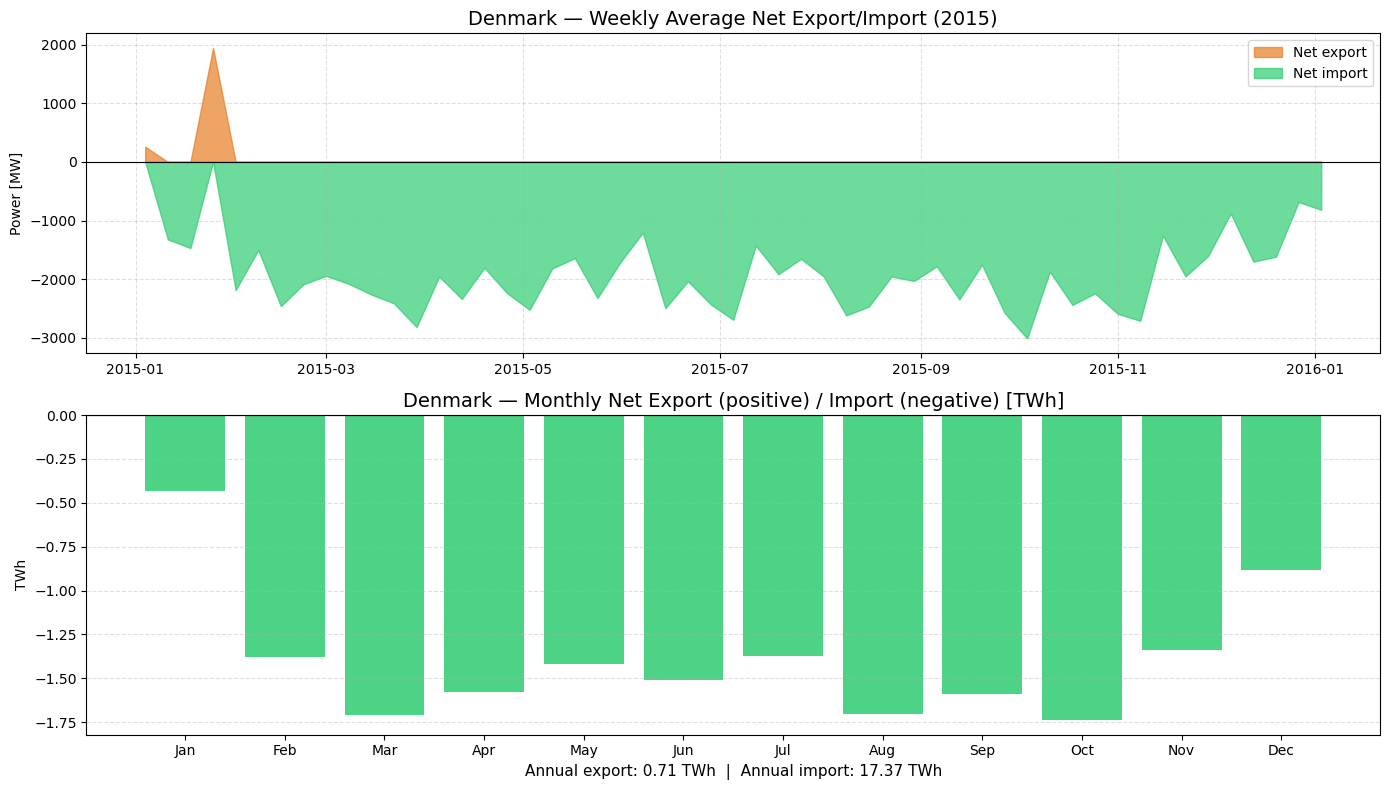

In [40]:
# ── CELL D12 ─────────────────────────────────────────────────
# Net export/import for Denmark over the year
importlib.reload(fti)
fti.plot_network_flows(net)


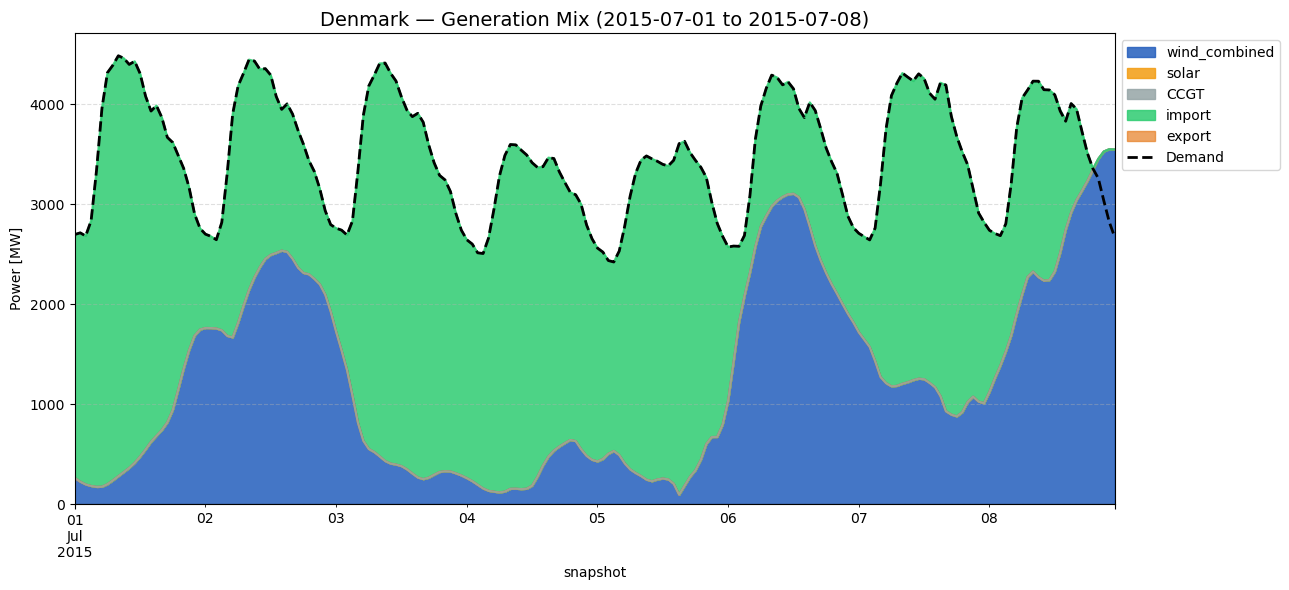

In [41]:
# ── CELL D13 — summer week dispatch for Denmark
fti.plot_generation_mix_network(net, "Denmark", '2015-07-01', '2015-07-08')


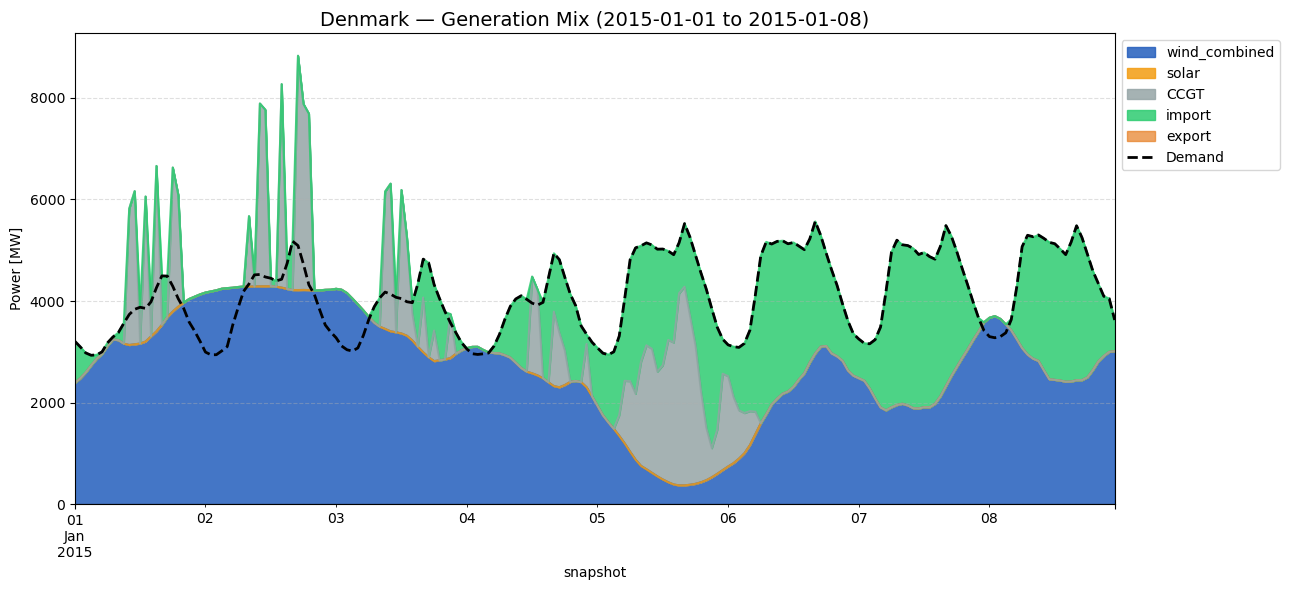

In [42]:
# ── CELL D14 — winter week dispatch for Denmark
fti.plot_generation_mix_network(net, "Denmark", '2015-01-01', '2015-01-08')


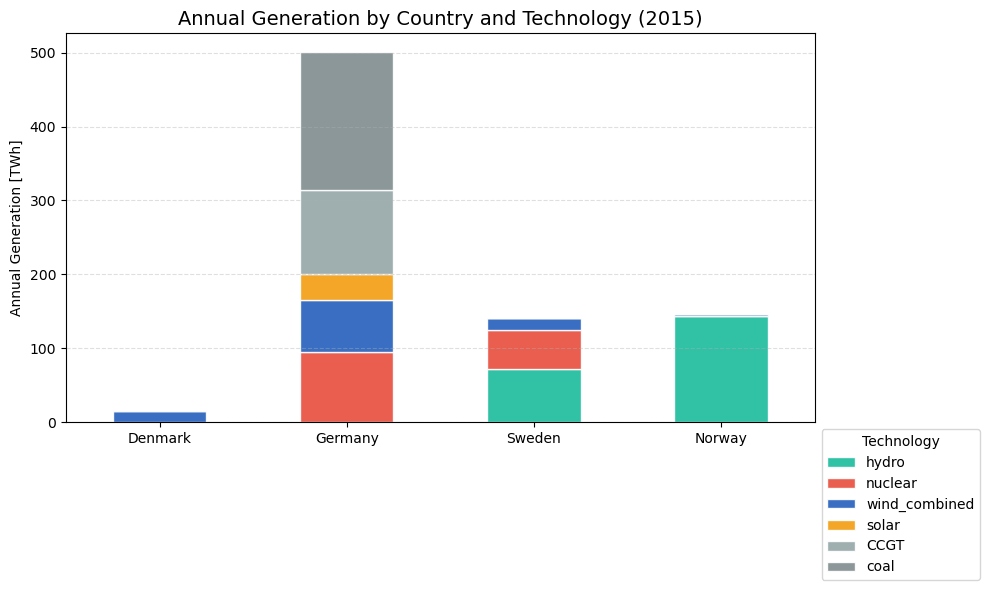

In [43]:
# ── CELL D15 — annual generation mix per country
fti.plot_annual_mix_all_countries(net)


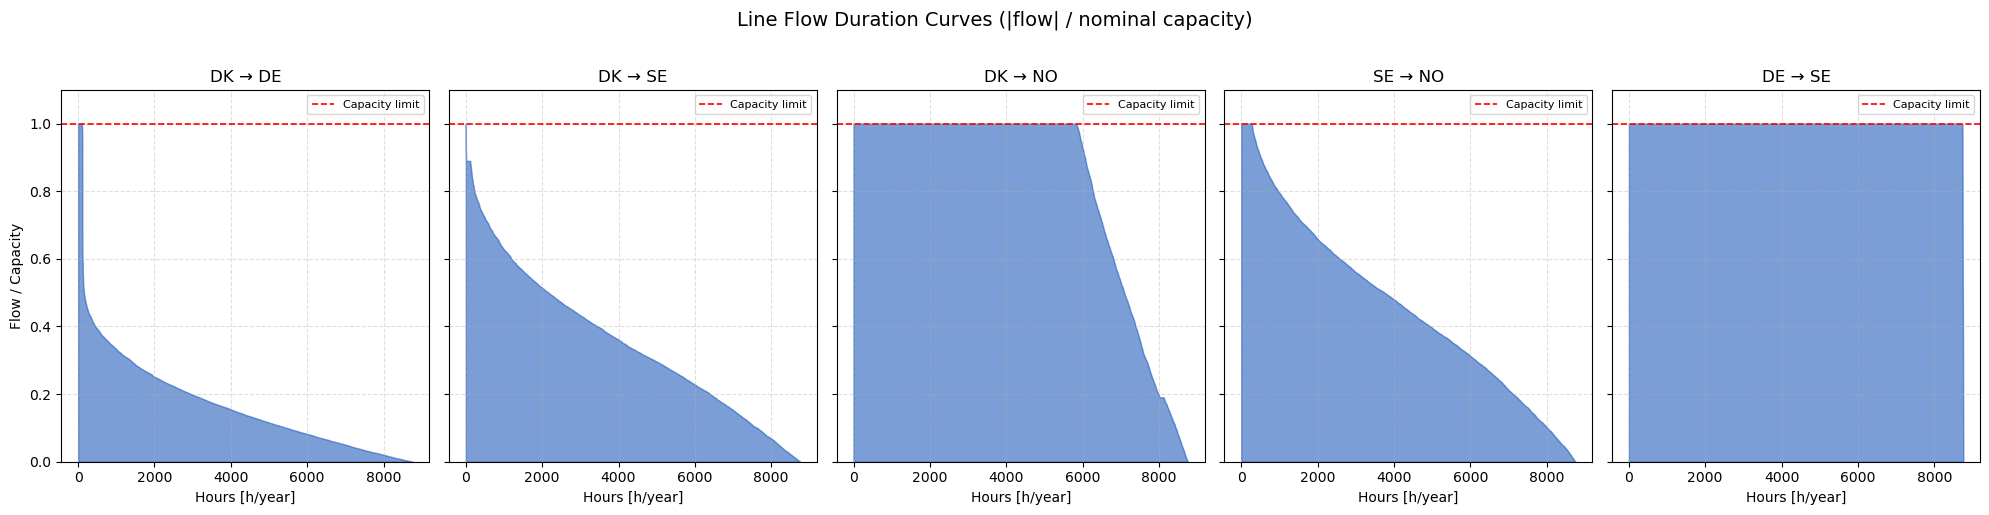

In [44]:
# ── CELL D16 — line flow duration curves
fti.plot_line_duration_curves(net)
